In [23]:
from sunpy.map import Map
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm
import matplotlib
from matplotlib import colors
import astropy.units as u
from astropy.coordinates import SkyCoord
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.widgets import Slider
import sys
import scipy as sp
from astropy.io import fits
import astropy.units as u
from sunpy.coordinates import frames

def weighted_centroid(data):
    # replace NaN
    data = np.nan_to_num(data, nan=0.0)
    
    ny, nx = data.shape
    
    # coordinate grid
    y, x = np.indices((ny, nx))
    
    # weights
    w = data
    
    total = np.sum(w)
    
    Cx = np.sum(x * w) / total
    Cy = np.sum(y * w) / total
    
    return Cx, Cy

In [24]:
path = r"D:\ATSOAA Sunpy Group Project\Data\2026_02_27"
sys.path.append(f'{path}')
ff = sorted(glob(f'{path}/*.fits'))
# print(ff)
# ff.info()

longitude = []
latitude = []



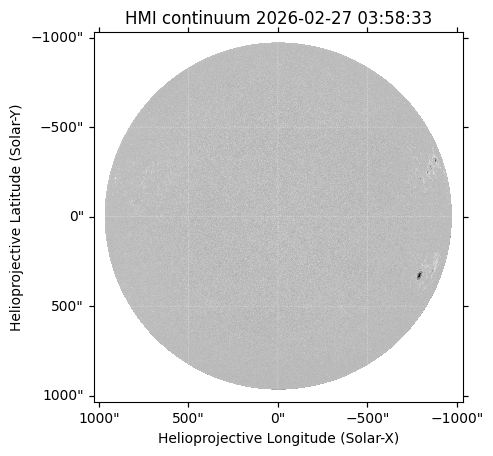

In [25]:
filename = ff[0]
m = Map(filename)
m.plot()
#plt.colorbar()
plt.show()

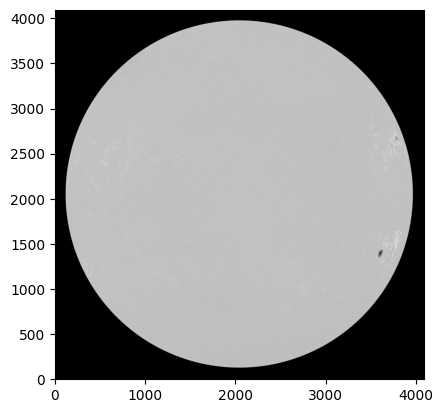

In [26]:
filename= ff[0]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

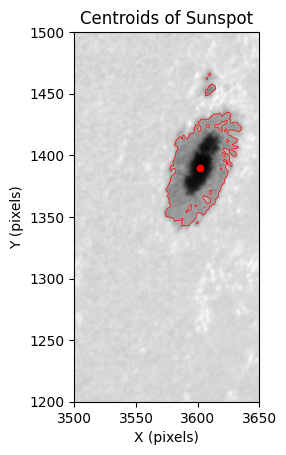

3601.544776119403 1389.7061567164178
-57d37m55.68807829s 16d12m27.70638312s


In [27]:
x0,x1 = 3500,3650
y0,y1 = 1200,1500

threshold = 0.6

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)



extent = [x0, x1, y0, y1]
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)
print(hg.lon, hg.lat)

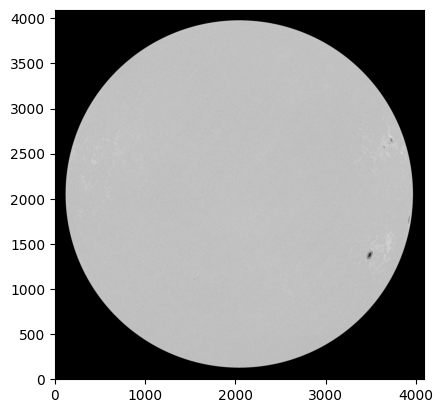

In [28]:
filename= ff[2]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

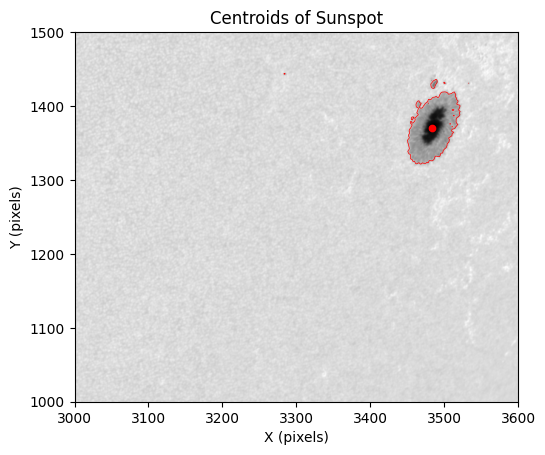

3484.0798544208947 1370.817169770927


In [29]:
x0,x1 = 3000,3600
y0,y1 = 1000,1500

threshold = 0.65

extent = [x0, x1, y0, y1]

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)

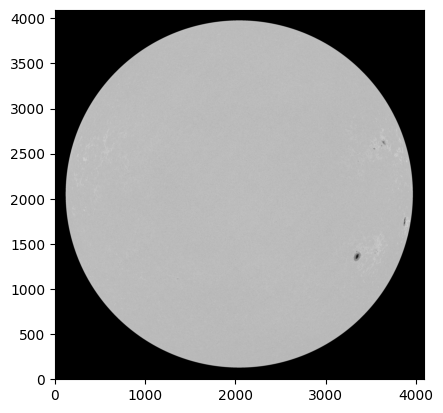

In [30]:
filename= ff[4]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

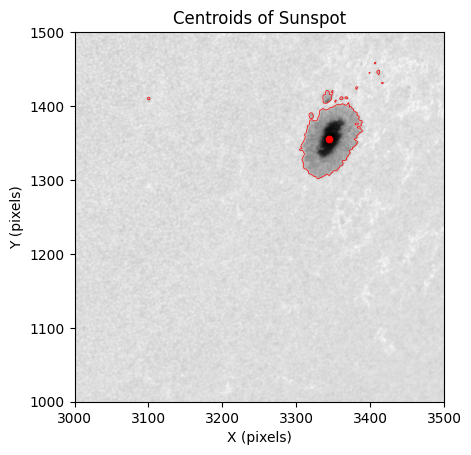

3344.920566396132 1355.8618546019686


In [31]:
x0,x1 = 3000,3500
y0,y1 = 1000,1500

threshold = 0.65

extent = [x0, x1, y0, y1]

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)

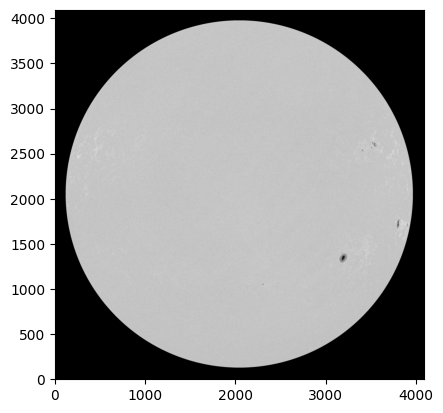

In [32]:
filename= ff[6]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

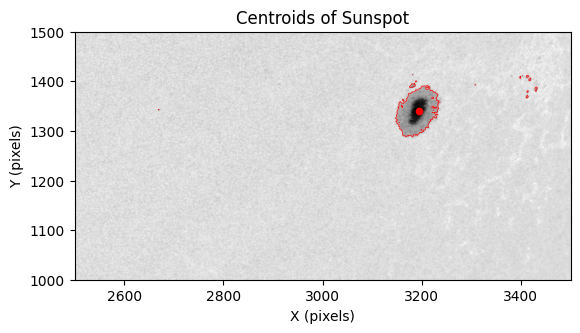

3193.611823480433 1339.7903413821814


In [33]:
x0,x1 = 2500,3500
y0,y1 = 1000,1500

threshold = 0.65

extent = [x0, x1, y0, y1]

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)

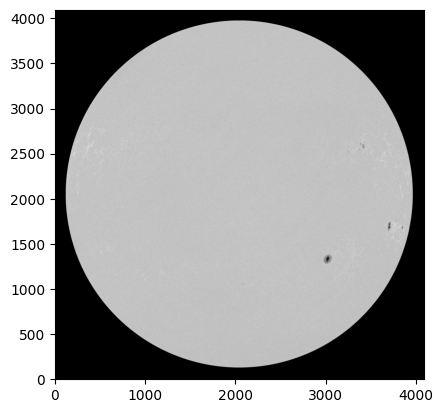

In [34]:
filename= ff[8]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

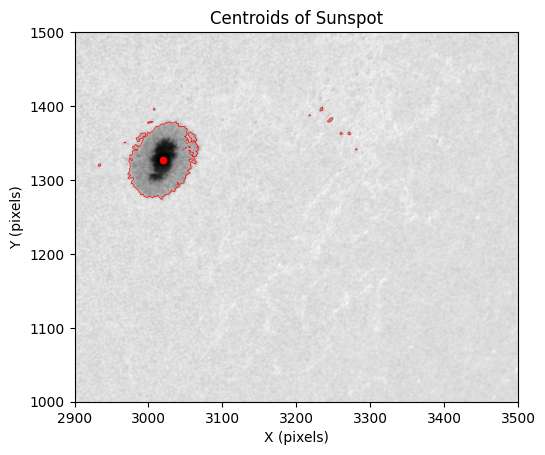

3020.2671676982022 1326.7705570291778


In [35]:
x0,x1 = 2900,3500
y0,y1 = 1000,1500

threshold = 0.65

extent = [x0, x1, y0, y1]

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)

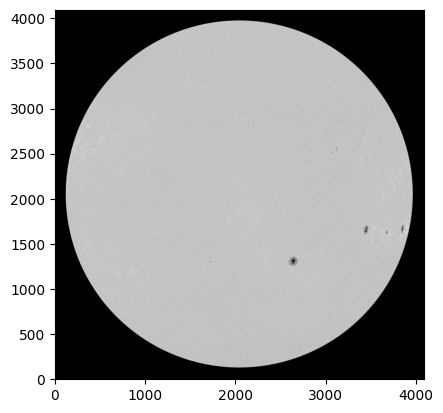

In [36]:
filename= ff[12]
m = Map(filename)
# hdu= fits.open(filename)[1] #Calling the first element of the HDU
data=m.data
header = m.meta
plt.imshow(data, cmap='gray')

data = np.nan_to_num(data, nan=0.0)
normalize_data = (data - data.min()) / (data.max() - data.min())
plt.imshow(normalize_data, cmap='gray',origin='lower')

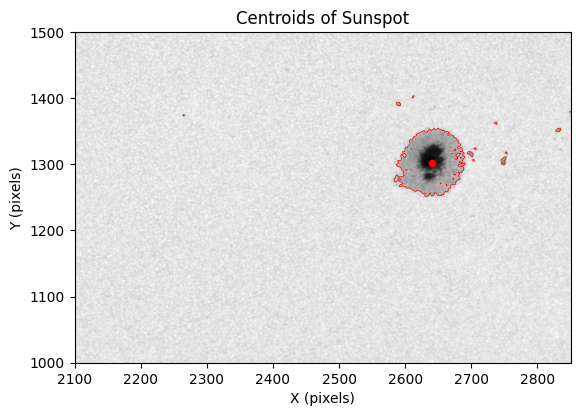

2640.695646489737 1302.4133873708981


In [37]:
x0,x1 = 2100,2850
y0,y1 = 1000,1500

threshold = 0.65

extent = [x0, x1, y0, y1]

binarized_image = (normalize_data[y0:y1,x0:x1] < threshold).astype(int)
Cx, Cy = weighted_centroid(binarized_image)
centroid_x = Cx + x0
centroid_y = Cy + y0
#pixel -> world

world_coord = m.pixel_to_world(centroid_x*u.pix, centroid_y*u.pix)

#world -> heliographic

hg = world_coord.transform_to(
    frames.HeliographicStonyhurst(obstime=m.date)
)
longitude.append(hg.lon)
latitude.append(hg.lat)

plt.imshow(normalize_data[y0:y1,x0:x1], origin='lower', cmap='gray', extent=extent)
plt.title('Centroids of Sunspot')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Assuming the white region is the second label (index 1) in 'centroid'
# and converting centroid coordinates to the plot's extent system
# The centroid output from OpenCV is (x, y) coordinates within the binarized_image slice.
# We need to add back the x0, y0 offsets to get the original image coordinates if needed,
# but for plotting on the cropped image, we just use the relative coordinates.

# Centroid is (x, y) in image coordinates, so centroid[1][0] is x-coord, centroid[1][1] is y-coord
centroid_x = Cx + x0
centroid_y = Cy + y0
plt.contour(normalize_data[y0:y1,x0:x1], levels=[threshold], colors='red', extent=extent, linewidths=0.5)
plt.scatter(centroid_x, centroid_y, marker='.', color='red', s=50, linewidth=2, label='Centroid of White Region')
# plt.legend()
plt.show()

print(centroid_x, centroid_y)

In [38]:
time = np.arange(len(longitude))
print(longitude)
# plt.plot(time, longitude, label='Longitude')

[<Longitude -57.63213558 deg>, <Longitude -51.25367384 deg>, <Longitude -44.80004059 deg>, <Longitude -38.47199384 deg>, <Longitude -31.9427737 deg>, <Longitude -18.93246122 deg>]


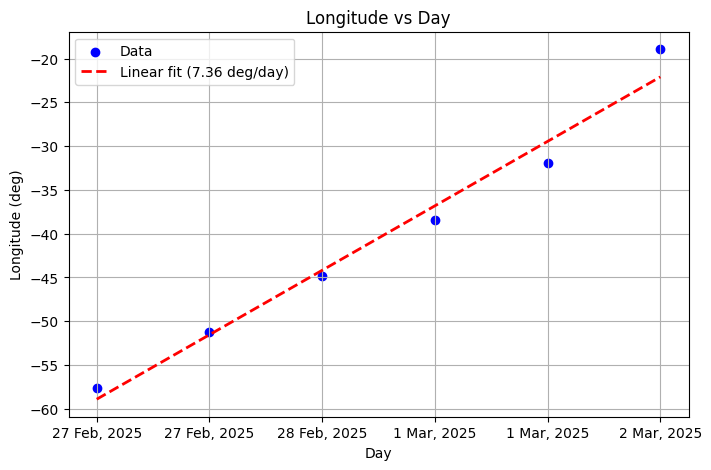

Slope = 7.3645 deg/day


In [43]:
import matplotlib.pyplot as plt

day_labels = ['27 Feb, 2025','27 Feb, 2025', '28 Feb, 2025','1 Mar, 2025', '1 Mar, 2025', '2 Mar, 2025']
x = np.arange(len(day_labels))
longitude_deg = u.Quantity(longitude).to_value(u.deg)

slope, intercept = np.polyfit(x, longitude_deg, 1)
x_fit = np.linspace(x.min(), x.max(), 200)
fit_line = slope * x_fit + intercept

plt.figure(figsize=(8, 5))
plt.scatter(x, longitude_deg, color='b', label='Data')
plt.plot(x_fit, fit_line, 'r--', linewidth=2, label=f'Linear fit ({slope:.2f} deg/day)')
plt.xticks(x, day_labels)
plt.xlabel("Day")
plt.ylabel("Longitude (deg)")
plt.title("Longitude vs Day")
plt.grid(True)
plt.legend()
plt.show()
print(f"Slope = {slope:.4f} deg/day")

In [40]:
time = np.arange(len(latitude))
print(latitude)
# plt.plot(time, latitude, label='Latitude')


[<Latitude 16.20769622 deg>, <Latitude 16.13116537 deg>, <Latitude 15.97971652 deg>, <Latitude 15.93914736 deg>, <Latitude 15.86198243 deg>, <Latitude 15.90732765 deg>]


In [41]:
import numpy as np
# Mean latitude from the stored array
latitude_deg = u.Quantity(latitude).to_value(u.deg)
lat = np.mean(latitude_deg)
print("Estimated latitude:", lat)

Estimated latitude: 16.004505924181014
